# Un drone vuelve a casa con una red de 3,4 kB

**3,84%.** Eso es todo lo que un drone Bee-Nav necesita explorar para aprender a regresar a casa desde 600 m de distancia. La red neuronal que lo guía pesa 3,4 kB — menos que este texto.

Una abeja melífera vuela el 3,4% de su zona para aprenderla. La pregunta que se hizo el equipo de TU Delft fue: ¿podemos copiar ese truco?

**Paper:** Ou et al. (2026) · *Nature* · [DOI: 10.1038/s41586-026-10461-3](https://doi.org/10.1038/s41586-026-10461-3)
**Datos:** [4TU.ResearchData (TU Delft)](https://doi.org/10.4121/a0217a20-0443-48b2-8a04-9609ac267029)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-13-bee-nav-navegacion-drones-abejas/notebook.ipynb)

> Video corto: [Pendiente]

## Lo que está en juego

Para navegar autónomamente, un drone normal carga GPS, mapas y algoritmos de localización y mapeo simultáneos (SLAM, por sus siglas en inglés) que consumen cómputo y memoria. El estado del arte para drones pequeñísimos: **500 kB de memoria solo para cubrir un área de 4×5 m** (20 m²).

Las abejas no llevan GPS. Cuando salen por primera vez de la colmena, hacen un *learning flight*: vuelos cortos en espiral alrededor de la casa, mirando hacia atrás para grabar referencias visuales. Después pueden volver desde kilómetros — sin mapa.

Bee-Nav copia esa idea. El drone hace su propio *learning flight* sobre una **Learning Area (LHA)**, entrena una red neuronal compacta con esas vistas, y luego puede volver desde mucho más lejos. La pregunta empírica: ¿qué tan pequeña puede ser esa LHA?

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
LHA_DRONE_BEE_NAV = 3.84      # %  del área que el drone Bee-Nav debe explorar
LHA_HONEYBEE      = 3.4       # %  estimado para abejas melíferas
LHA_DESERT_ANT    = 7.6       # %  estimado para hormigas del desierto
RED_COMPACT_KB    = 3.4       # kB red neural Bee-Nav (5 capas)
RED_ATTENTION_KB  = 42.3      # kB red neural Bee-Nav con atención (8 capas)
SOTA_TINY_KB      = 500       # kB SOTA tiny drone para 4x5m

FUENTE = 'Fuente: Ou et al. (2026), Nature | Datos: 4TU.ResearchData (TU Delft)'
COLOR_DATOS     = '#2563EB'   # azul CaM — Bee-Nav
COLOR_ALERTA    = '#DC2626'   # rojo — referencia/anomalía
COLOR_REFERENCIA= '#D97706'   # ámbar — biológico
COLOR_BIO       = '#059669'   # verde — biología
COLOR_OTROS     = '#7C3AED'   # violeta — métodos alternativos

# ══════════════════════════════════════════════════════════════
# Setup
# ══════════════════════════════════════════════════════════════
import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'

# Cargar estilo CaM (local → GitHub raw fallback)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# ══════════════════════════════════════════════════════════════
# Carga de datos
# ══════════════════════════════════════════════════════════════
lha     = pd.read_csv('datos/lha_por_metodo.csv')
redes   = pd.read_csv('datos/redes_neuronales.csv')
homing  = pd.read_csv('datos/homing_por_ambiente.csv')
sim     = pd.read_csv('datos/visual_homing_simulacion.csv')

print(f'LHA por método:     {len(lha)} filas')
print(f'Redes neuronales:   {len(redes)} filas')
print(f'Homing por ambiente: {len(homing)} filas')
print(f'Simulación homing:  {len(sim)} filas')
print()
print('Métodos LHA y su % del área:')
for _, r in lha.sort_values('lha_pct').iterrows():
    print(f'  {r["metodo"]:30s}  LHA = {r["lha_pct"]:.2f}%')

LHA por método:     5 filas
Redes neuronales:   3 filas
Homing por ambiente: 6 filas
Simulación homing:  7 filas

Métodos LHA y su % del área:
  bio_inspired_magnetometer       LHA = 0.24%
  svo_gtsam                       LHA = 0.74%
  honeybee_estimate               LHA = 3.40%
  real_drone_bee_nav              LHA = 3.84%
  desert_ant_estimate             LHA = 7.60%


## Aquí está.

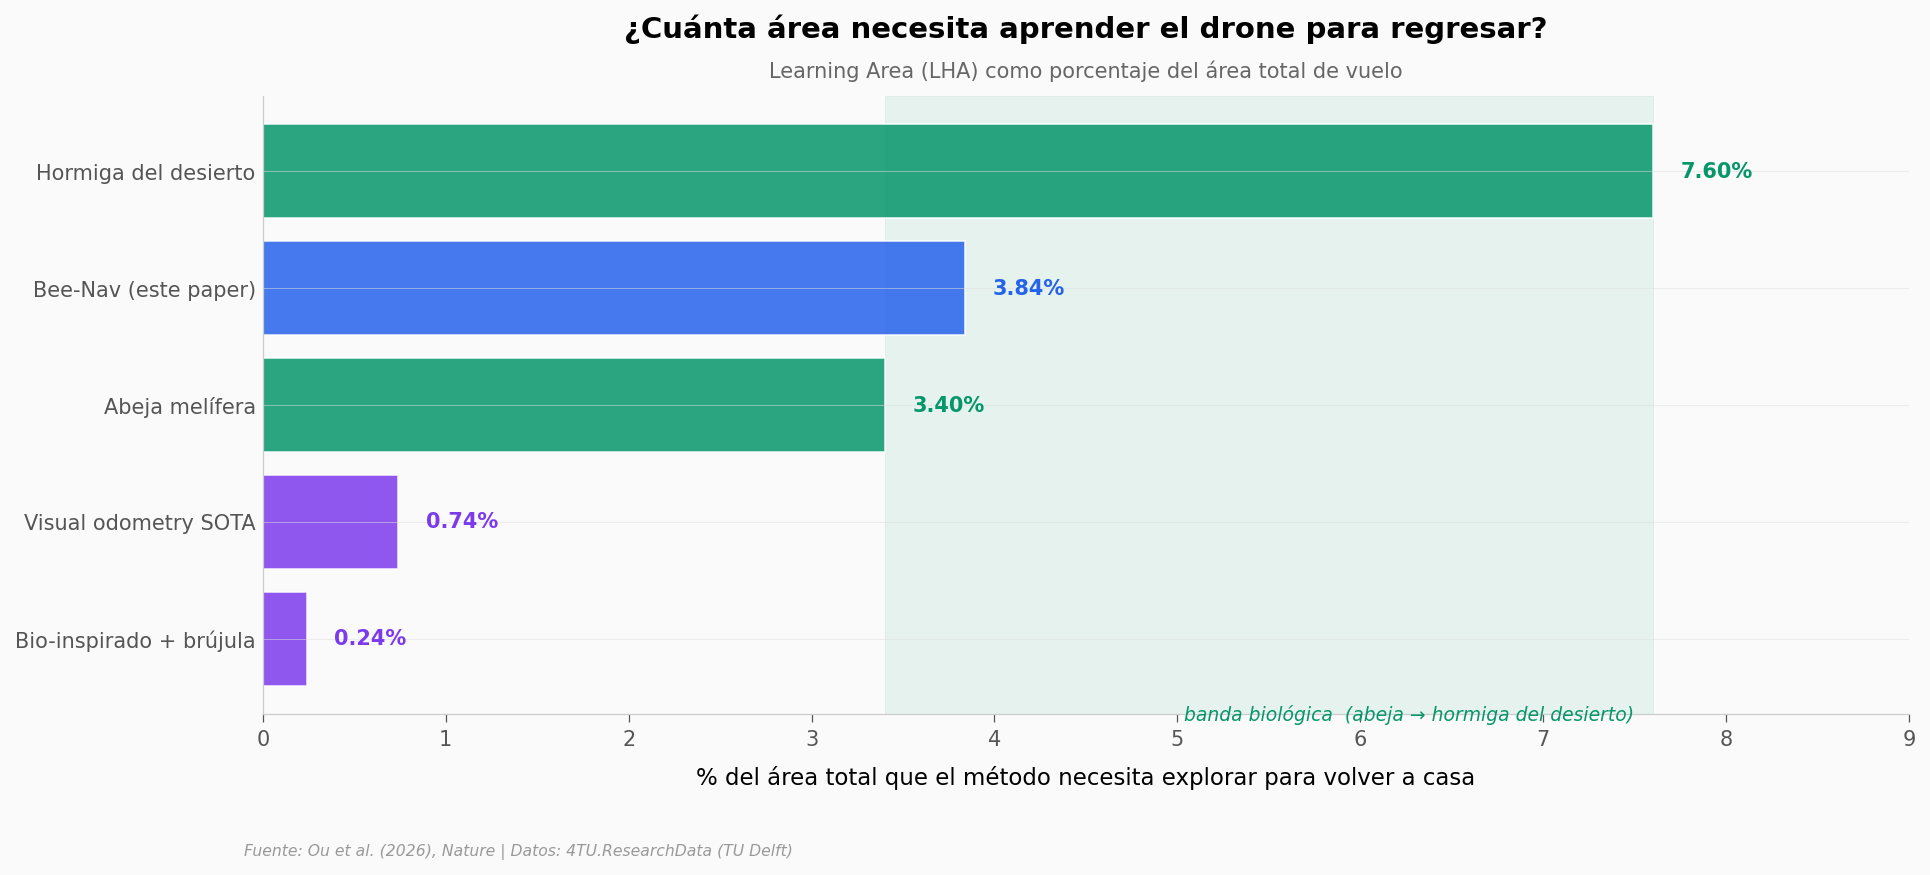

In [2]:
# Hero: LHA% por método — drone real, alternativas, referencia biológica
# Ordenamos ascendente para que la lectura visual sea de "menos área" a "más área"
df = lha.copy()
df['categoria'] = df['metodo'].map({
    'real_drone_bee_nav':       'Bee-Nav (este paper)',
    'svo_gtsam':                'Visual odometry SOTA',
    'bio_inspired_magnetometer':'Bio-inspirado + brújula',
    'honeybee_estimate':        'Abeja melífera',
    'desert_ant_estimate':      'Hormiga del desierto',
})
df['color'] = df['metodo'].map({
    'real_drone_bee_nav':       COLOR_DATOS,
    'svo_gtsam':                COLOR_OTROS,
    'bio_inspired_magnetometer':COLOR_OTROS,
    'honeybee_estimate':        COLOR_BIO,
    'desert_ant_estimate':      COLOR_BIO,
})
df = df.sort_values('lha_pct').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 5.5))
y_pos = np.arange(len(df))
bars = ax.barh(y_pos, df['lha_pct'], color=df['color'], alpha=0.85,
               edgecolor='white', linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(df['categoria'], fontsize=10)

# Etiquetas en las barras
for i, (val, lbl) in enumerate(zip(df['lha_pct'], df['categoria'])):
    ax.text(val + 0.15, i, f'{val:.2f}%', va='center',
            fontsize=10, fontweight='bold', color=df.loc[i,'color'])

# Banda biológica de referencia (3.4 - 7.6%)
ax.axvspan(LHA_HONEYBEE, LHA_DESERT_ANT, alpha=0.08, color=COLOR_BIO, zorder=0)
ax.text(LHA_DESERT_ANT - 0.1, -0.7,
        'banda biológica  (abeja → hormiga del desierto)',
        fontsize=9, ha='right', color=COLOR_BIO, style='italic')

ax.set_xlabel('% del área total que el método necesita explorar para volver a casa',
              fontsize=11)
ax.set_title('¿Cuánta área necesita aprender el drone para regresar?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Learning Area (LHA) como porcentaje del área total de vuelo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(0, 9)

fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/01_lha_por_metodo.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que dice la barra

El drone Bee-Nav real (azul) cae justo encima de la abeja melífera. Con 3,84% del área aprendida vuelve a casa; la abeja, con un 3,4% estimado, también.

Pero comparar drone y abeja como si fueran lo mismo sería engañoso. Las dos cifras vienen de mecanismos distintos: el drone usa odometría visual sobre sus motores y giroscopios; la abeja integra señales celestes, ópticas y olfativas. Lo que coincide es la **estrategia** — explorar una zona pequeña al principio para construir un mapa interno — no la implementación.

Los dos métodos alternativos (violeta) son interesantes por la dirección opuesta. **SVO+GTSAM** es odometría visual de estado del arte: como tiene menos error acumulado, le basta el 0,74% del área. **Bio-inspirado + brújula** lleva incluso heading absoluto vía magnetómetro, así que solo necesita el 0,24%. El drone Bee-Nav, sin brújula y con sensores baratos, pierde precisión pero gana simplicidad — y sigue dentro de la banda biológica.

## ¿Cuánto pesa el cerebro del drone?

La otra parte del truco está en el tamaño de la red neuronal que aprende durante el *learning flight*. Aquí Bee-Nav se desmarca.

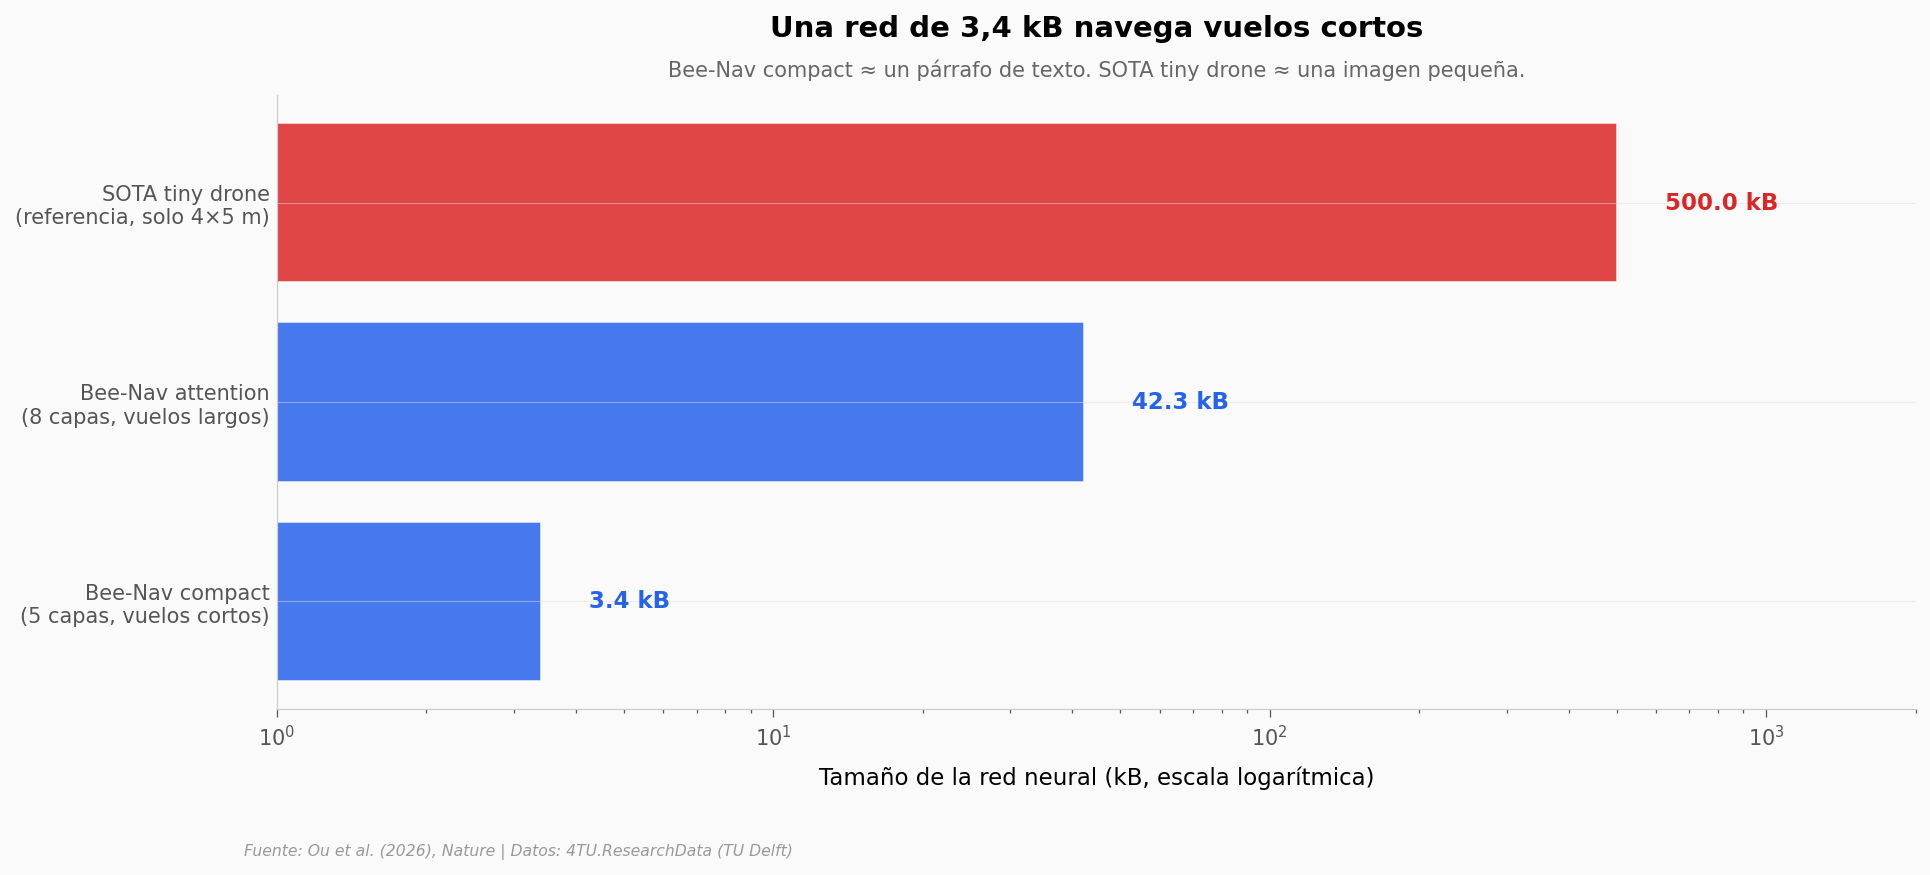

attention / compact      = 12.4x
SOTA tiny / attention    = 11.8x


In [3]:
# Gráfica 2: tamaño de red neural (log scale para comprimir 3 órdenes de magnitud)
df = redes.copy().sort_values('tamano_kb').reset_index(drop=True)
df['categoria'] = df['red'].map({
    'compact':              'Bee-Nav compact\n(5 capas, vuelos cortos)',
    'attention':            'Bee-Nav attention\n(8 capas, vuelos largos)',
    'tiny_robot_referencia':'SOTA tiny drone\n(referencia, solo 4×5 m)',
})
df['color'] = df['red'].map({
    'compact':              COLOR_DATOS,
    'attention':            COLOR_DATOS,
    'tiny_robot_referencia':COLOR_ALERTA,
})

fig, ax = plt.subplots(figsize=(13, 5.5))
y_pos = np.arange(len(df))
bars = ax.barh(y_pos, df['tamano_kb'], color=df['color'], alpha=0.85,
               edgecolor='white', linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(df['categoria'], fontsize=10)
ax.set_xscale('log')

# Etiquetas con valor a la derecha de cada barra
for i, val in enumerate(df['tamano_kb']):
    ax.text(val * 1.25, i, f'{val:.1f} kB', va='center',
            fontsize=11, fontweight='bold', color=df.loc[i,'color'])

ax.set_xlabel('Tamaño de la red neural (kB, escala logarítmica)', fontsize=11)
ax.set_title('Una red de 3,4 kB navega vuelos cortos',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Bee-Nav compact ≈ un párrafo de texto. SOTA tiny drone ≈ una imagen pequeña.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(1, 2000)

fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/02_tamano_red.png', dpi=200, bbox_inches='tight')
plt.show()

# Ratios para acompañar
ratio_atn_compact = RED_ATTENTION_KB / RED_COMPACT_KB
ratio_sota_atn    = SOTA_TINY_KB     / RED_ATTENTION_KB
print(f'attention / compact      = {ratio_atn_compact:.1f}x')
print(f'SOTA tiny / attention    = {ratio_sota_atn:.1f}x')

## ¿Y en el mundo real?

Las redes diminutas suenan bien en simulación. La prueba dura es volar afuera, con viento, sin GPS, y aterrizar cerca de casa.

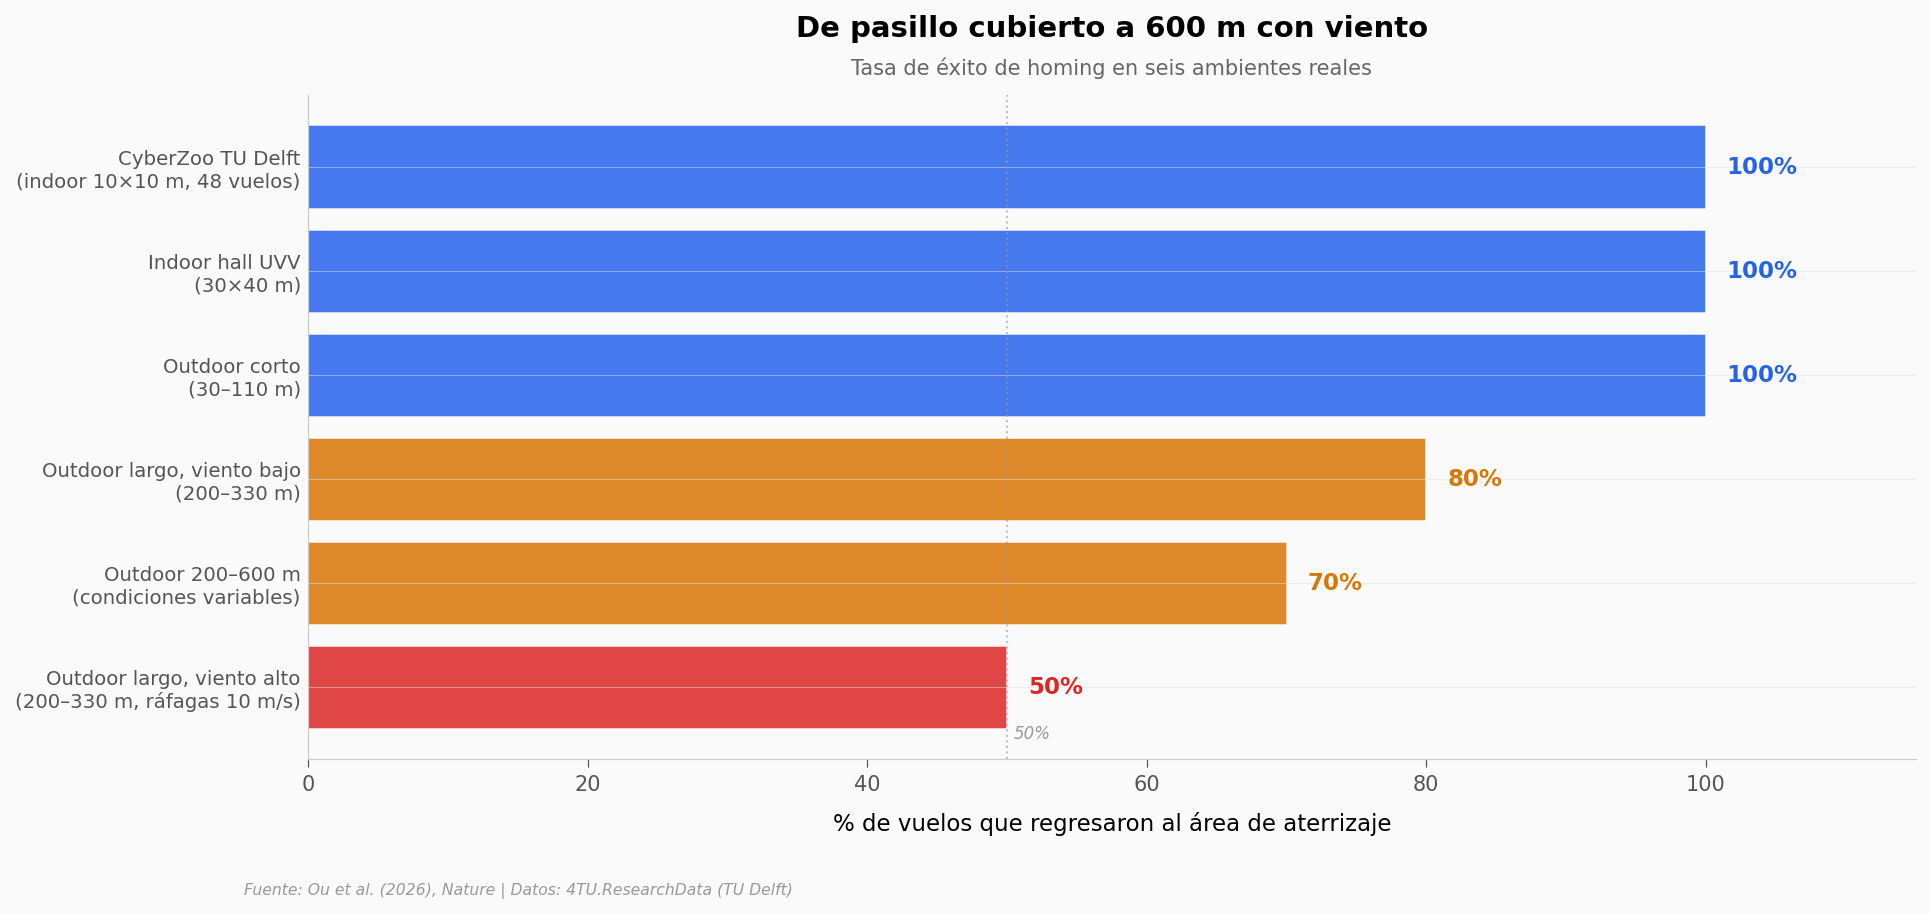

Caída por viento alto (mismo rango 200-330m): 30 puntos porcentuales


In [4]:
# Gráfica 3: tasa de éxito por ambiente, de fácil a difícil
df = homing.copy()
df['etiqueta'] = [
    'CyberZoo TU Delft\n(indoor 10×10 m, 48 vuelos)',
    'Indoor hall UVV\n(30×40 m)',
    'Outdoor corto\n(30–110 m)',
    'Outdoor largo, viento bajo\n(200–330 m)',
    'Outdoor largo, viento alto\n(200–330 m, ráfagas 10 m/s)',
    'Outdoor 200–600 m\n(condiciones variables)',
]
# Ordenar por tasa de éxito descendente para lectura clara
df = df.sort_values('tasa_exito_pct', ascending=False).reset_index(drop=True)

def color_por_tasa(t):
    if t >= 95: return COLOR_DATOS       # azul — éxito alto
    if t >= 70: return COLOR_REFERENCIA  # ámbar — éxito medio
    return COLOR_ALERTA                  # rojo — éxito bajo

colors = [color_por_tasa(t) for t in df['tasa_exito_pct']]

fig, ax = plt.subplots(figsize=(13, 5.8))
y_pos = np.arange(len(df))
bars = ax.barh(y_pos, df['tasa_exito_pct'], color=colors, alpha=0.85,
               edgecolor='white', linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(df['etiqueta'], fontsize=9.5)
ax.invert_yaxis()  # Más fácil arriba

for i, val in enumerate(df['tasa_exito_pct']):
    ax.text(val + 1.5, i, f'{val:.0f}%', va='center',
            fontsize=11, fontweight='bold', color=colors[i])

# Línea vertical en 50% (azar para binario aterriza-cerca / no-aterriza)
ax.axvline(x=50, color='#999999', linestyle=':', linewidth=1, alpha=0.6)
ax.text(50.5, len(df) - 0.5, '50%', fontsize=8, color='#999999', style='italic')

ax.set_xlim(0, 115)
ax.set_xlabel('% de vuelos que regresaron al área de aterrizaje', fontsize=11)
ax.set_title('De pasillo cubierto a 600 m con viento',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Tasa de éxito de homing en seis ambientes reales',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/03_exito_ambiente.png', dpi=200, bbox_inches='tight')
plt.show()

# Caída por viento alto
drop_viento = 80 - 50
print(f'Caída por viento alto (mismo rango 200-330m): {drop_viento} puntos porcentuales')

## ¿Hasta dónde generaliza?

Una pregunta crítica: el drone aprende dentro de la Learning Area. ¿Qué pasa cuando se aleja? ¿Sigue sabiendo volver?

Para responderlo, el equipo corrió **800 vuelos simulados** en 10 bosques sintéticos distintos (40 árboles cada uno) y compararon Bee-Nav con dos métodos de referencia: *snapshot* clásico y *perfect memory*.

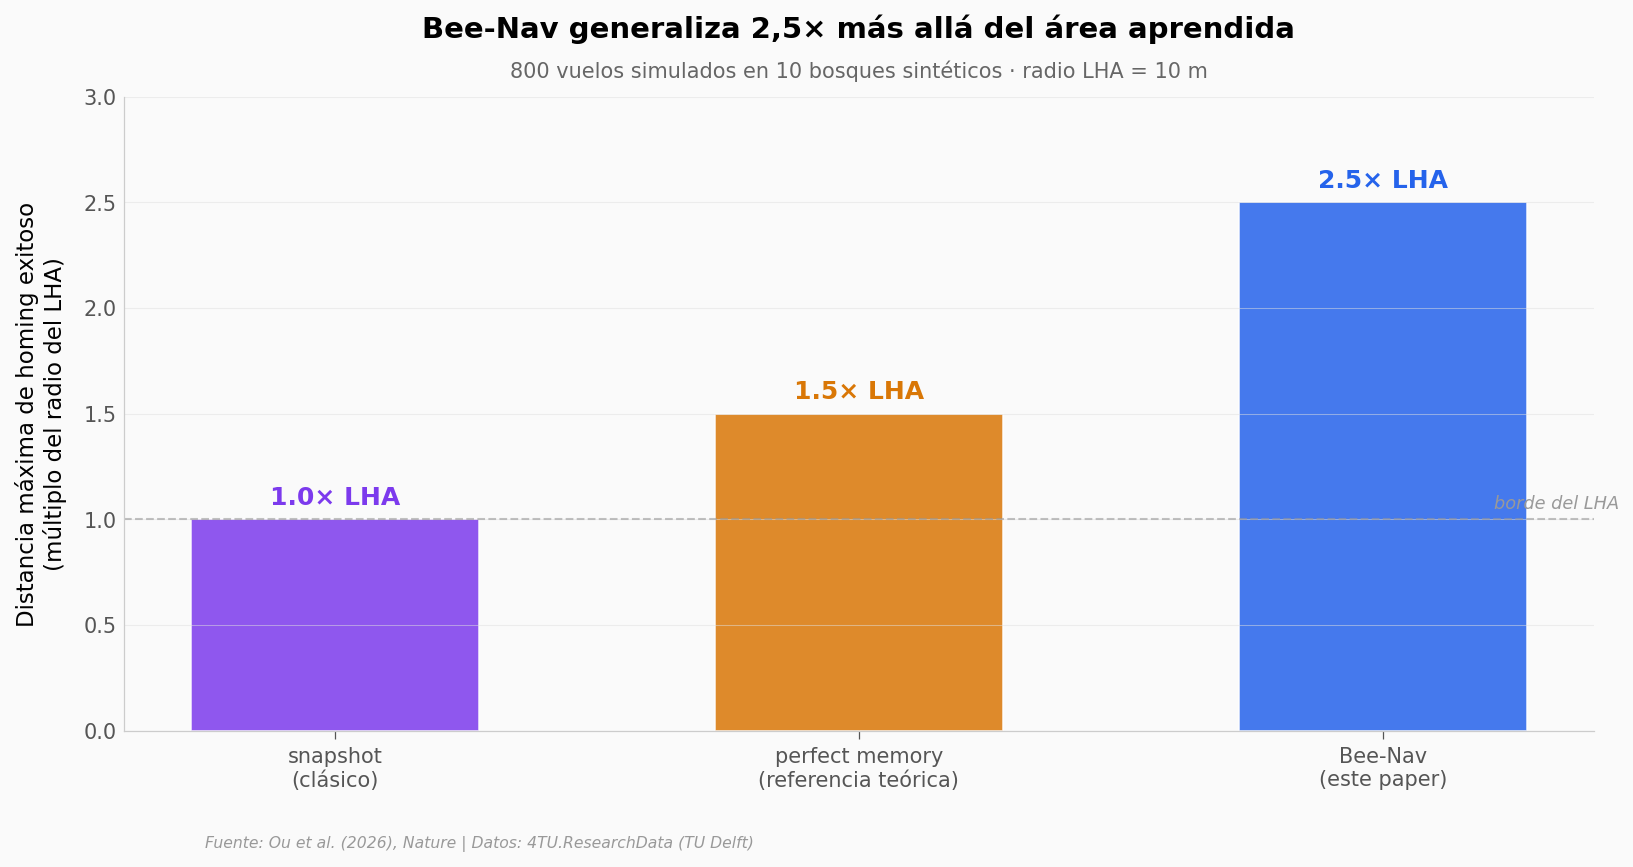

Bee-Nav generaliza 2.5× más lejos que snapshot clásico
Bee-Nav generaliza 1.67× más lejos que perfect memory teórico


In [5]:
# Cierre cuantitativo: hasta dónde generaliza cada método (múltiplo del radio LHA)
# Aplicando excepción benchmark de regla 6: 3 métodos discretos sin distribución temporal
metodos = ['snapshot\n(clásico)', 'perfect memory\n(referencia teórica)', 'Bee-Nav\n(este paper)']
generaliza = [1.0, 1.5, 2.5]
colors = [COLOR_OTROS, COLOR_REFERENCIA, COLOR_DATOS]

fig, ax = plt.subplots(figsize=(11, 5.5))
positions = np.arange(len(metodos))
bars = ax.bar(positions, generaliza, color=colors, alpha=0.85,
              edgecolor='white', linewidth=0.8, width=0.55)
ax.set_xticks(positions)
ax.set_xticklabels(metodos, fontsize=10)

for i, val in enumerate(generaliza):
    ax.text(i, val + 0.07, f'{val:.1f}× LHA', ha='center',
            fontsize=12, fontweight='bold', color=colors[i])

# Línea horizontal en 1.0 = el borde del LHA
ax.axhline(y=1.0, color='#999999', linestyle='--', linewidth=1, alpha=0.6)
ax.text(2.45, 1.05, 'borde del LHA', fontsize=8.5, ha='right',
        color='#999999', style='italic')

ax.set_ylim(0, 3.0)
ax.set_ylabel('Distancia máxima de homing exitoso\n(múltiplo del radio del LHA)',
              fontsize=11)
ax.set_title('Bee-Nav generaliza 2,5× más allá del área aprendida',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        '800 vuelos simulados en 10 bosques sintéticos · radio LHA = 10 m',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/04_generalizacion.png', dpi=200, bbox_inches='tight')
plt.show()

# Ratio Bee-Nav vs snapshot
print(f'Bee-Nav generaliza {2.5/1.0:.1f}× más lejos que snapshot clásico')
print(f'Bee-Nav generaliza {2.5/1.5:.2f}× más lejos que perfect memory teórico')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|:-----------:|---------|
| El drone real necesita explorar 3,84% del área para volver a casa | ✅ | Reportado en Results sobre datos PX4 reales (Fig 2b). Coincide con la banda biológica (3,4–7,6%). |
| La red neural Bee-Nav compact mide 3,4 kB; attention 42,3 kB | ✅ | Conteo directo de parámetros × bits — verificable. SOTA tiny drone usa 500 kB para 4×5 m (Bardienus 2024). |
| Bee-Nav generaliza hasta 2,5× el radio del LHA | ✅ | 800 vuelos simulados en 10 bosques sintéticos. *Snapshot* clásico falla a 1,0×; *perfect memory* llega a 1,5×. |
| 100% de éxito en vuelos cortos exteriores (30–110 m); 70% en vuelos largos (200–600 m) | ✅ | 48 vuelos en CyberZoo, n no detallado en UVV. El 70% del abstract incluye condiciones variables de viento. |
| El viento alto reduce 30 puntos porcentuales la tasa de éxito | ✅ | 80% con viento bajo → 50% con viento alto (ráfagas de 10 m/s) en el mismo rango 200–330 m. |
| El drone "iguala" al cerebro de la abeja | ⚠️ | El LHA% del drone (3,84%) coincide con el estimado para abejas (3,4%), pero el mecanismo es distinto. El paper lo describe como una verificación preliminar de la estrategia, no como equivalencia funcional. |

> **Limitaciones:** (1) Los LHA% de abeja y hormiga son **estimaciones derivadas de comportamiento natural**, no medidas directas — son referencias de magnitud, no de precisión. (2) Los conteos n por ambiente outdoor no se publican explícitamente, solo se reporta la tasa. (3) Los 800 vuelos de simulación corren en bosques sintéticos uniformes (40 árboles en 50×50 m); el mundo real tiene mucha más heterogeneidad. (4) El raw dataset (716 MB en 4TU.ResearchData, formato PX4 .ulg + ROS2 bags) no se procesó en este notebook por tamaño y por no ser didáctico — los valores cuantitativos vienen del texto del paper y su Supplementary.

## Ahora tú

1. **¿Y si bajamos el LHA del drone?** Cambia `LHA_DRONE_BEE_NAV = 3.84` por `2.0` en la celda de configuración y vuelve a correr la primera gráfica. ¿Sigue dentro de la banda biológica?

2. **¿Cuántas veces más pesa el SOTA tiny drone que Bee-Nav compact?** Calcula `SOTA_TINY_KB / RED_COMPACT_KB`. ¿Por cuál factor podrías meter la red de Bee-Nav?

3. **¿A qué tasa de éxito caerías si combinas ambos efectos: distancia larga + viento alto?** Pista: en el dataset `homing`, filtra por `outdoor_200_330m_high_wind` y compara con `outdoor_30_110m_UVV`.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 2 del bloque "Ahora tú": cuántas veces más pesa el SOTA que Bee-Nav compact

factor_compact   = SOTA_TINY_KB / RED_COMPACT_KB
factor_attention = SOTA_TINY_KB / RED_ATTENTION_KB

print(f'SOTA tiny drone pesa {factor_compact:.0f}× más que Bee-Nav compact')
print(f'SOTA tiny drone pesa {factor_attention:.1f}× más que Bee-Nav attention')
print()
print(f'En el espacio de UN SOTA tiny drone caben:')
print(f'  {factor_compact:.0f}   redes Bee-Nav compact')
print(f'  o  {factor_attention:.1f}  redes Bee-Nav attention')

# Bonus: ¿cuánto cubre Bee-Nav vs SOTA por kB de memoria?
# SOTA: 500 kB → 20 m² (4x5)
# Bee-Nav compact: 3.4 kB → al menos 110 m de radio efectivo
sota_m2_por_kB    = 20 / SOTA_TINY_KB
beenav_m_por_kB   = 110 / RED_COMPACT_KB  # vuelos 30-110m exitosos al 100%
print()
print(f'Eficiencia espacial (orden de magnitud):')
print(f'  SOTA tiny:    {sota_m2_por_kB:.3f} m² / kB')
print(f'  Bee-Nav compact: ~{beenav_m_por_kB:.0f} m / kB (radio efectivo)')

SOTA tiny drone pesa 147× más que Bee-Nav compact
SOTA tiny drone pesa 11.8× más que Bee-Nav attention

En el espacio de UN SOTA tiny drone caben:
  147   redes Bee-Nav compact
  o  11.8  redes Bee-Nav attention

Eficiencia espacial (orden de magnitud):
  SOTA tiny:    0.040 m² / kB
  Bee-Nav compact: ~32 m / kB (radio efectivo)


## Créditos

**Repo CaM:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)
**Licencia:** Notebook bajo MIT. Datos del paper son Open Access (CC BY 4.0 vía Nature).

## Fuentes

**Paper**: [Efficient robot navigation inspired by honeybee learning flights](https://doi.org/10.1038/s41586-026-10461-3)  
*Nature, 2026-05-13*

**Datos**: [Bee-Nav: Data supporting the publication 'Efficient robot navigation inspired by honeybee learning flights'](https://doi.org/10.4121/a0217a20-0443-48b2-8a04-9609ac267029)  
*4TU.ResearchData (TU Delft), 2026-04-10 — raw dataset (716 MB, formato PX4 .ulg + ROS2 bags) no procesado en este notebook; CSVs construidos desde los valores cuantitativos publicados en el texto del paper Open Access.*

*24 afirmaciones del notebook verificadas contra estas fuentes*